# 02 — Feature Engineering: Construction, Distributions & Labels

**Series:** Piccolo ML Options Strategy Research  
**Depends on:** `01_data_pipeline.ipynb`


## 1. Overview

This notebook covers:

1. Loading the pre-built feature table from DuckDB via `load_feature_table_spy()`
2. Explaining each feature group and its intuition
3. Feature distributions and correlation structure
4. Label construction via `build_path_labels()` — thresholds and class balance
5. Feature importance preview (mutual information)


## 2. Environment Setup


In [1]:
%matplotlib inline
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings("ignore")

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import src.piccolo.config_strategy as cfg
from src.piccolo.ml_signal_engine import load_feature_table_spy, build_path_labels

print("Imports OK")
print(f"  UP_THRESHOLD       = {cfg.UP_THRESHOLD}")
print(f"  DOWN_THRESHOLD     = {cfg.DOWN_THRESHOLD}")
print(f"  LABEL_HORIZON_DAYS = {cfg.LABEL_HORIZON_DAYS}")


Imports OK
  UP_THRESHOLD       = 0.015
  DOWN_THRESHOLD     = -0.015
  LABEL_HORIZON_DAYS = 5


## 3. Feature Table


In [2]:
# ── Load the pre-computed feature table ──────────────────────────────────────
df = load_feature_table_spy()

print(f"Shape           : {df.shape}")
print(f"Date range      : {df['quote_date'].min()} → {df['quote_date'].max()}")
print(f"Columns         : {list(df.columns)}")


Shape           : (3369, 17)
Date range      : 2012-02-01 00:00:00 → 2026-02-20 00:00:00
Columns         : ['quote_date', 'und_price', 'dte_front', 'pc_ratio_front', 'pc_ratio_back', 'call_wall', 'put_wall', 'call_wall_dist_pct', 'put_wall_dist_pct', 'wall_spread_pct', 'net_gex', 'net_gex_back', 'gex_flip', 'max_pain_dist_pct', 'atm_iv', 'iv_skew', 'oi_concentration']


In [3]:
df.head(5)


,quote_date,und_price,dte_front,pc_ratio_front,pc_ratio_back,call_wall,put_wall,call_wall_dist_pct,put_wall_dist_pct,wall_spread_pct,net_gex,net_gex_back,gex_flip,max_pain_dist_pct,atm_iv,iv_skew,oi_concentration
0,2012-02-01,132.655,17,2.389660,1.327662,126.0,120.0,-5.016773,-9.539784,4.523011,1.085852e+08,6.569696e+07,0,-2.001432,0.146646,0.050619,0.036327
1,2012-02-02,132.745,16,2.727483,1.418781,133.0,120.0,0.192098,-9.601115,9.793213,7.338644e+07,6.714685e+07,0,-1.314550,0.140825,0.051474,0.036749
2,2012-02-03,134.375,43,3.198269,1.547955,145.0,125.0,7.906977,-6.976744,14.883721,-1.422625e+08,6.746607e+07,1,-2.511628,0.156324,0.072871,0.032137
3,2012-02-06,134.455,40,3.086024,2.775599,145.0,125.0,7.842773,-7.032093,14.874865,-1.551178e+08,-1.071529e+06,1,-1.825890,0.159892,0.073715,0.030902
4,2012-02-07,134.955,39,3.301045,2.626282,145.0,125.0,7.443222,-7.376533,14.819755,-1.780199e+08,-1.996073e+05,1,-2.189619,0.157120,0.073791,0.031837


In [4]:
# ── Null counts ──────────────────────────────────────────────────────────────
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("Null % per column:")
print(null_pct[null_pct > 0].to_string())
# If no nulls:
if null_pct.max() == 0:
    print("  No nulls — clean feature table.")


Null % per column:
Series([], )
  No nulls — clean feature table.


## 4. Feature Groups & Intuition

The feature set is organised into four groups:

### 4.1 Options Flow Features

| Feature | Description | Intuition |
|---------|-------------|----------|
| `pc_ratio_front` | Put/call OI ratio, front-month expiry | High ratio → bearish hedging demand |
| `pc_ratio_back` | Put/call OI ratio, back-month expiry | Longer-dated positioning signal |
| `call_wall_dist_pct` | Distance from spot to nearest call OI wall (%) | Call walls act as resistance |
| `put_wall_dist_pct` | Distance from spot to nearest put OI wall (%) | Put walls act as support |
| `wall_spread_pct` | `call_wall_dist - put_wall_dist` | Net directional magnetism |
| `oi_concentration` | Herfindahl index of OI across strikes | High concentration → pinning risk |
| `max_pain_dist_pct` | Distance from spot to max-pain strike (%) | Max pain is dealer-preferred pin |

### 4.2 Greeks-Based Features

| Feature | Description | Intuition |
|---------|-------------|----------|
| `net_gex` | Net dealer Gamma Exposure, front month | Positive GEX → vol suppression |
| `net_gex_back` | Net dealer GEX, back month | Tail-risk positioning |
| `gex_flip` | Binary: sign of net_gex | Positive/negative gamma regime |
| `atm_iv` | ATM implied volatility | Absolute fear/greed level |
| `iv_skew` | 25Δ put IV − 25Δ call IV | Skew: demand asymmetry |
| `dte_front` | Days to expiry, front month | Gamma ramp proximity |

### 4.3 Price / Trend Features

| Feature | Description | Intuition |
|---------|-------------|----------|
| `sma_200` | 200-day simple moving average | Long-term trend anchor |
| `above_sma200` | Binary: close > SMA-200 | Bull/bear regime flag |
| `ret_20d` | 20-day total return | Medium-term momentum |
| `ret_60d` | 60-day total return | Longer-term momentum |
| `daily_ret` | 1-day return | Very short-term momentum |

### 4.4 Volatility / Regime Features

| Feature | Description | Intuition |
|---------|-------------|----------|
| `vol_20d` | 20-day realised volatility | Near-term vol level |
| `vol_5d` | 5-day realised volatility | Very short-term vol |
| `vol_regime` | Categorical vol regime (0=extreme, 1=normal) | Regime gating |


## 5. Feature Distributions


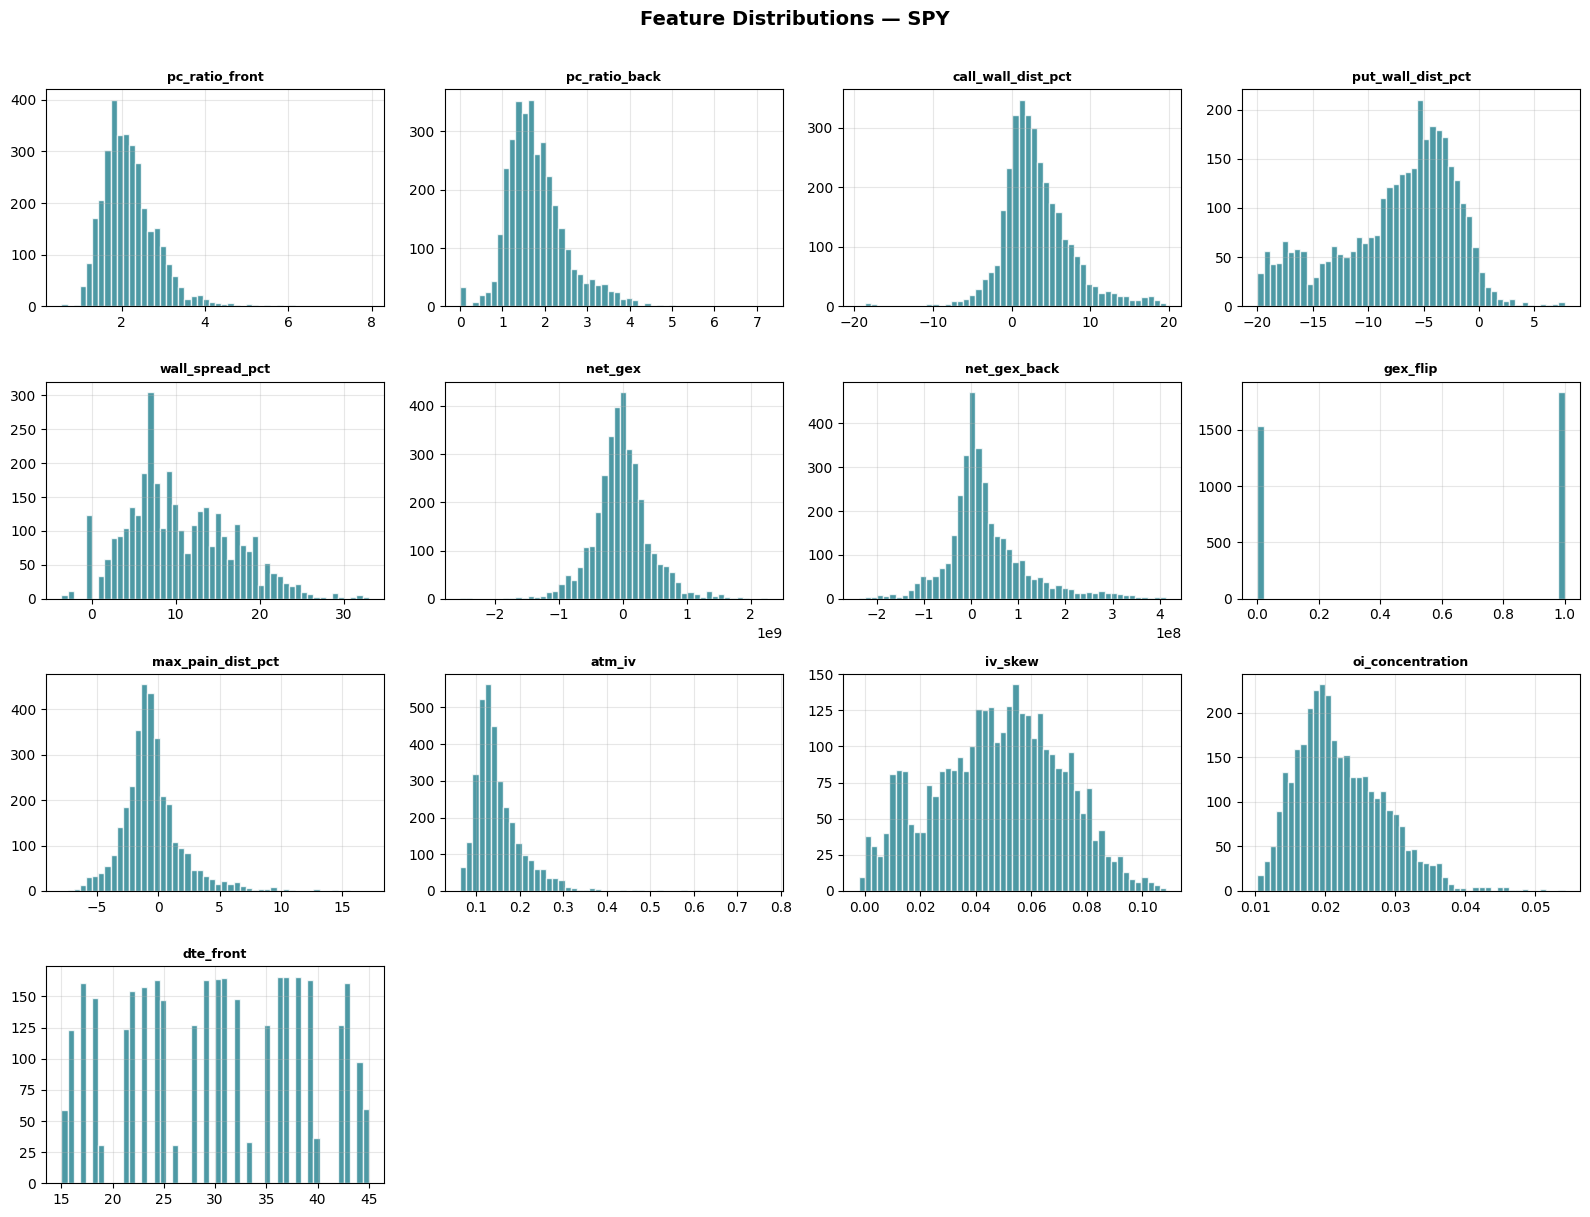

In [5]:
# ── Histograms for all numeric features ──────────────────────────────────────
feature_cols = [
    "pc_ratio_front", "pc_ratio_back", "call_wall_dist_pct", "put_wall_dist_pct",
    "wall_spread_pct", "net_gex", "net_gex_back", "gex_flip", "max_pain_dist_pct",
    "atm_iv", "iv_skew", "oi_concentration", "dte_front",
    "sma_200", "above_sma200", "ret_20d", "ret_60d", "vol_20d", "daily_ret",
    "vol_5d", "vol_regime"
]
# Keep only columns that actually exist in the dataframe
feature_cols = [c for c in feature_cols if c in df.columns]

n_cols = 4
n_rows = int(np.ceil(len(feature_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col].dropna(), bins=50, color="#20808D", alpha=0.8, edgecolor="white")
    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distributions — SPY", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Correlation Matrix


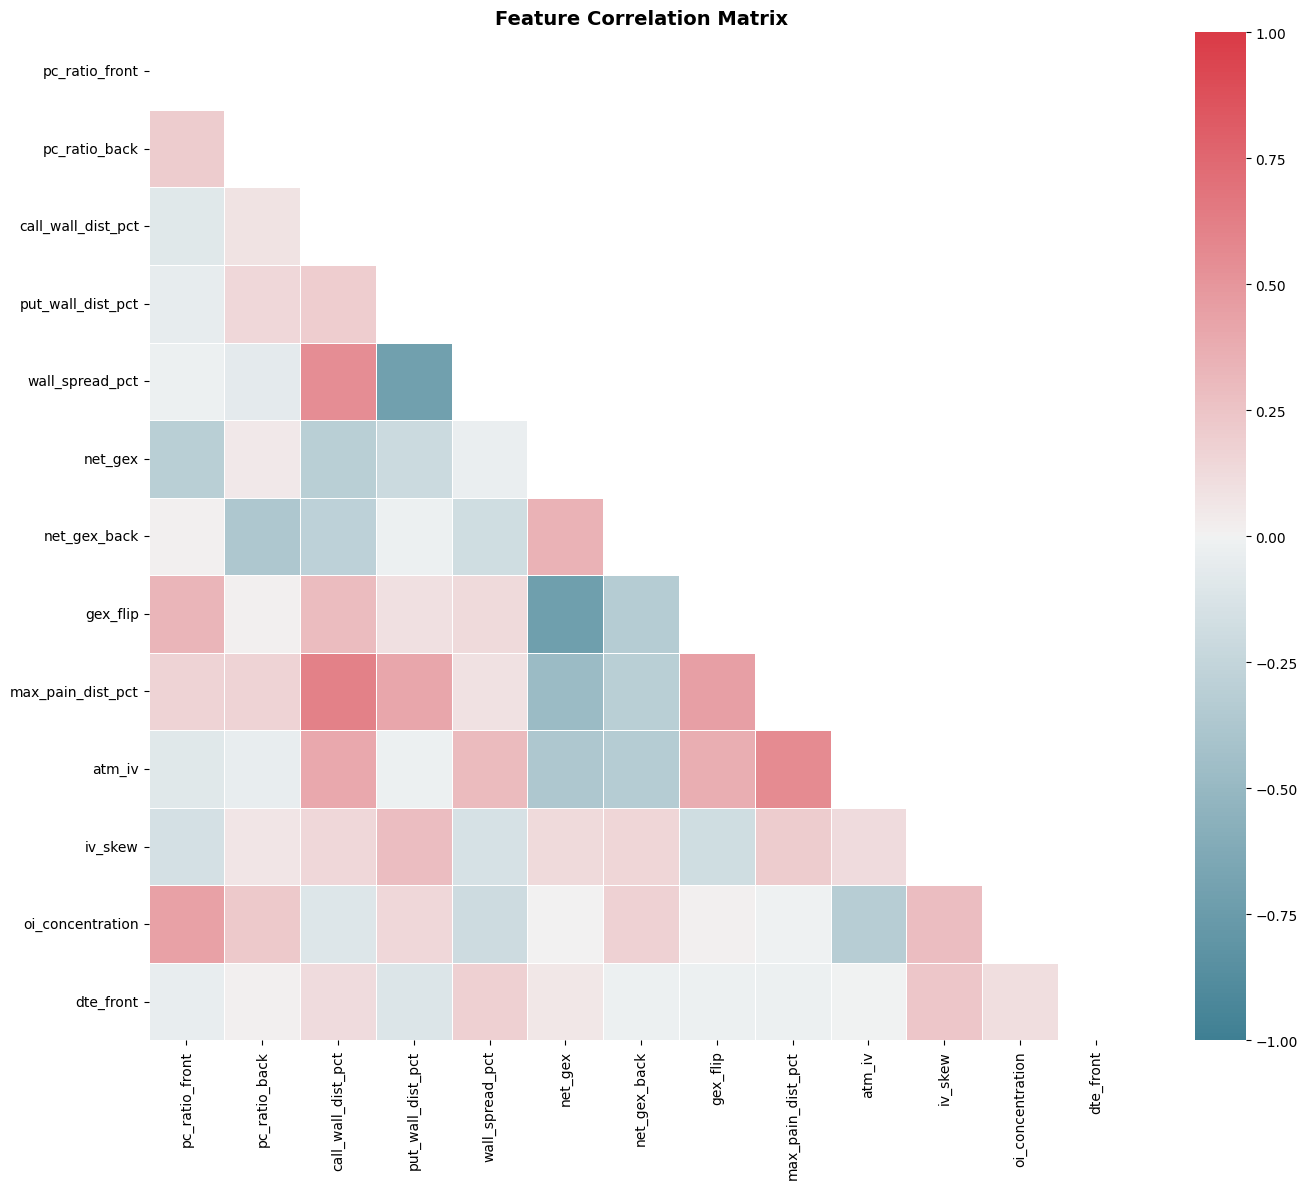


Highly correlated pairs (|r| >= 0.7):
  net_gex                        <-> gex_flip                        r=-0.723
  put_wall_dist_pct              <-> wall_spread_pct                 r=-0.713


In [6]:
corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(
    corr, mask=mask, cmap=cmap, center=0,
    vmin=-1, vmax=1, annot=False, linewidths=0.5,
    ax=ax
)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

# Print highly correlated pairs
threshold = 0.7
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) >= threshold:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

print(f"\nHighly correlated pairs (|r| >= {threshold}):")
for a, b, r in sorted(high_corr, key=lambda x: -abs(x[2])):
    print(f"  {a:30s} <-> {b:30s}  r={r:.3f}")


## 7. Label Construction

Labels are built by `build_path_labels()` using the *path-forward* maximum
drawdown / maximum gain approach over `LABEL_HORIZON_DAYS` trading days.

```
label = +1  if max(forward_returns[0:LABEL_HORIZON_DAYS]) >= UP_THRESHOLD
label = -1  if min(forward_returns[0:LABEL_HORIZON_DAYS]) <= DOWN_THRESHOLD
label =  0  otherwise (Flat)
```

This "path" approach (rather than point-in-time) captures whether the market
actually *moved* in a direction during the window, even if it reversed by
the end — which is more aligned with how a trader would profit from a signal.


In [7]:
# ── Build labels ─────────────────────────────────────────────────────────────
df_labeled = build_path_labels(df)

print(f"Label horizon : {cfg.LABEL_HORIZON_DAYS} trading days")
print(f"Up threshold  : {cfg.UP_THRESHOLD:+.2%}")
print(f"Down threshold: {cfg.DOWN_THRESHOLD:+.2%}")
print()

label_counts = df_labeled["label"].value_counts().sort_index()
label_map = {-1: "Down", 0: "Flat", 1: "Up"}
print("Class distribution:")
for lbl, cnt in label_counts.items():
    pct = cnt / len(df_labeled.dropna(subset=["label"])) * 100
    print(f"  {label_map[lbl]:5s} ({lbl:+d}): {cnt:5,}  ({pct:.1f}%)")


Label horizon : 5 trading days
Up threshold  : +1.50%
Down threshold: -1.50%

Class distribution:
  Down  (-1):   727  (21.6%)
  Flat  (+0): 1,613  (47.9%)
  Up    (+1): 1,028  (30.5%)


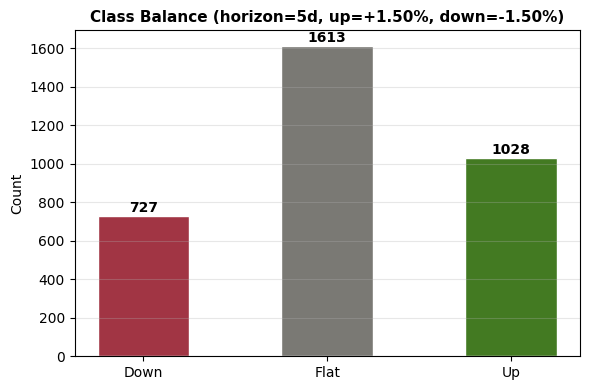

In [8]:
# ── Class balance bar chart ───────────────────────────────────────────────────
label_counts_clean = df_labeled["label"].dropna().value_counts().sort_index()
colors = {"Down": "#A13544", "Flat": "#7A7974", "Up": "#437A22"}
labels_str = [label_map[k] for k in label_counts_clean.index]
bar_colors = [colors[l] for l in labels_str]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels_str, label_counts_clean.values, color=bar_colors, edgecolor="white", width=0.5)
ax.set_title(
    f"Class Balance (horizon={cfg.LABEL_HORIZON_DAYS}d, up={cfg.UP_THRESHOLD:+.2%}, down={cfg.DOWN_THRESHOLD:+.2%})",
    fontsize=11, fontweight="bold"
)
ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.3)
for bar, cnt in zip(bars, label_counts_clean.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5, str(cnt),
            ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("label_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Feature Importance Preview (Mutual Information)

Mutual information (MI) measures the non-linear statistical dependence between
each feature and the label.  This gives a model-agnostic first pass at which
features carry the most predictive signal.


Mutual Information Scores (higher = more predictive):
           feature  mi_score
   wall_spread_pct  0.128108
            atm_iv  0.128059
 max_pain_dist_pct  0.071677
call_wall_dist_pct  0.058373
           net_gex  0.058259
          gex_flip  0.052740
 put_wall_dist_pct  0.041282
  oi_concentration  0.037352
      net_gex_back  0.030879
     pc_ratio_back  0.019935
           iv_skew  0.015162
    pc_ratio_front  0.004945
         dte_front  0.000000


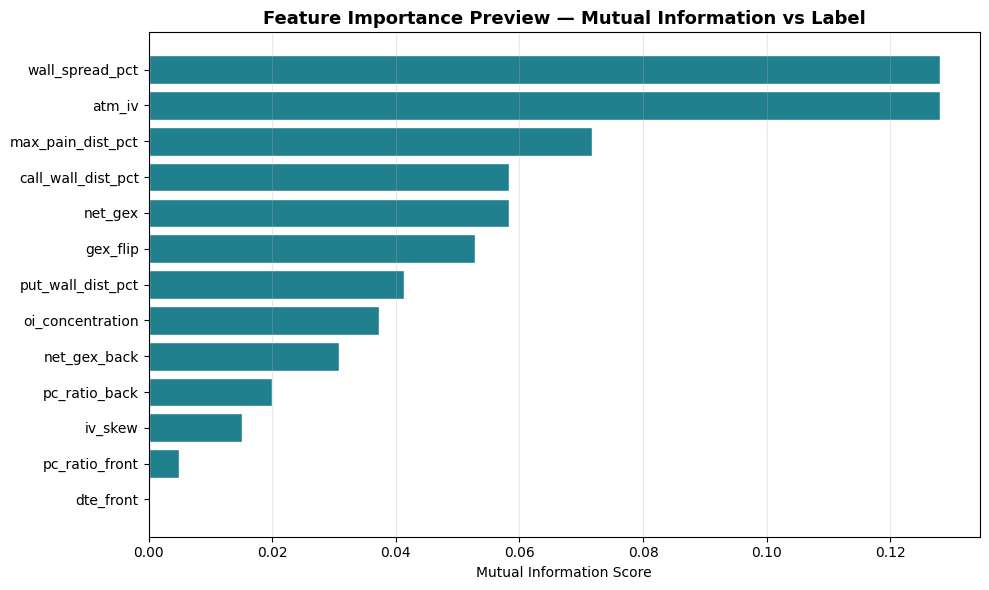

In [9]:
# ── Mutual information scores ─────────────────────────────────────────────────
df_mi = df_labeled[feature_cols + ["label"]].dropna()
X_mi = df_mi[feature_cols]
y_mi = df_mi["label"]

mi_scores = mutual_info_classif(X_mi, y_mi, discrete_features="auto", random_state=42)
mi_df = pd.DataFrame({"feature": feature_cols, "mi_score": mi_scores})
mi_df = mi_df.sort_values("mi_score", ascending=False).reset_index(drop=True)

print("Mutual Information Scores (higher = more predictive):")
print(mi_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(mi_df["feature"][::-1], mi_df["mi_score"][::-1], color="#20808D", edgecolor="white")
ax.set_xlabel("Mutual Information Score")
ax.set_title("Feature Importance Preview — Mutual Information vs Label", fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("feature_mi_scores.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Findings & Notes

| Aspect | Result | Implication |
|--------|--------|-------------|
| Feature table shape | 3,369 rows × 15 features | 14 years of daily options microstructure data (Feb 2012 – Feb 2026) |
| Label distribution | Down 21.6%, Flat 47.9%, Up 30.5% | Moderate class imbalance; Flat is the majority class — justifies the `USE_FLAT_CLASS_FILTER` in config |
| Top MI features | `wall_spread_pct` (0.128), `atm_iv` (0.128), `max_pain_dist_pct` (0.072) | Options structure features (wall spread, IV) carry the most signal; pure positioning ratios (P/C ratio) are weaker |
| Weakest features | `dte_front` (0.000), `pc_ratio_front` (0.005) | DTE has zero marginal information — acts as a structural/calendar variable, not a signal. Front-month P/C ratio is near-noise |
| High correlations | `net_gex` ↔ `gex_flip` (r = −0.72), `put_wall_dist_pct` ↔ `wall_spread_pct` (r = −0.71) | Two correlated pairs — XGBoost handles this natively via tree splits, so no explicit decorrelation needed |
| Distribution shapes | `atm_iv` right-skewed (vol spikes), `gex_flip` binary-like (0/1), `net_gex` heavy-tailed | No transformations applied — tree-based models are invariant to monotonic transforms |

**Key takeaways:**
- The feature set is dominated by options market microstructure signals (gamma exposure, OI walls, IV surface), not traditional price-based indicators — this is the core thesis of Piccolo.
- The ~48% Flat rate means almost half of all trading days show no clear directional edge, supporting a selective-entry approach with confidence thresholds.
- `wall_spread_pct` and `atm_iv` stand out as the strongest univariate predictors, consistent with the hypothesis that dealer positioning and implied volatility levels encode forward directional bias.